# CSE 445: Loan Approval Prediction using Machine Learning

**Objective**: Build a machine learning model to predict loan approval status using applicant financial and demographic data.

**Dataset**: loan_approval_data.csv (614 rows, 20 features)

**Models**: Logistic Regression, Decision Tree, AdaBoost

**Key Metric**: F1-Score (balances precision and recall for imbalanced data)

---

## 1. Setup & Import Libraries

Import all necessary libraries for data handling, visualization, and machine learning.

In [1]:
# Set random seeds FIRST for reproducibility across all runs
import os
os.environ['PYTHONHASHSEED'] = '42'
import numpy as np
np.random.seed(42)
import random
random.seed(42)

# Data handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Metrics & Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## ⚙️ Setup Instructions

Simply place `loan_approval_data.csv` in the same directory as this notebook and run!


## 2. Data Cleaning & Missing Value Handling (10 marks)

**Objective:** Identify and appropriately handle missing values with clear justification.

**Strategy:**
- **Numeric columns** → Fill with **MEAN**: Mean imputation preserves the statistical distribution and is suitable for numerical features with missing-at-random patterns.
- **Categorical columns** → Fill with **MODE**: Mode (most frequent value) is the statistically sound approach for categorical data, minimizing information loss.
- **Alternative methods rejected:**
  - Deletion: Would reduce dataset size and lose information
  - Forward fill: Not applicable for non-time-series data
  - Predictive imputation: Adds complexity without significant benefit for this dataset size

In [2]:
# Load dataset - Simple and fast
import os

print("📁 Loading CSV File")
print("="*50)

# Try current directory first
if os.path.exists('loan_approval_data.csv'):
    df = pd.read_csv('loan_approval_data.csv')
    print("✓ Successfully loaded: loan_approval_data.csv")
else:
    # Try parent directory
    if os.path.exists('../loan_approval_data.csv'):
        df = pd.read_csv('../loan_approval_data.csv')
        print("✓ Successfully loaded from parent directory")
    else:
        print("❌ File not found in current or parent directory")
        print("Please ensure loan_approval_data.csv is in the notebook folder")
        raise FileNotFoundError("loan_approval_data.csv not found")

print(f"\n✓ Dataset Shape: {df.shape}")
print("\nFirst 5 rows:")
print(df.head())


📁 Loading CSV File
✓ Successfully loaded: loan_approval_data.csv

✓ Dataset Shape: (10000, 20)

First 5 rows:
   Applicant_ID  Applicant_Income  Coapplicant_Income Employment_Status   Age  \
0           1.0           17795.0              1387.0          Salaried  51.0   
1           2.0            2860.0              2679.0          Salaried  46.0   
2           3.0            7390.0              2106.0          Salaried  25.0   
3           4.0           13964.0              8173.0          Salaried  40.0   
4           5.0           13284.0              4223.0     Self-employed  31.0   

  Marital_Status  Dependents  Credit_Score  Existing_Loans  DTI_Ratio  \
0        Married         0.0         637.0             4.0       0.53   
1        Married         3.0         621.0             2.0       0.30   
2         Single         2.0         674.0             4.0       0.20   
3        Married         2.0         579.0             3.0       0.31   
4         Single         2.0         7

In [ ]:
# Data already loaded - proceeding to analysis
print("✓ Ready for analysis")

In [ ]:
# Check data types and missing values
print("Data Info:")
print(df.info())
print("\n" + "="*50 + "\n")

# Count missing values
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_count.index,
    'Missing_Count': missing_count.values,
    'Missing_Percent': missing_percent.values
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)

print("Missing Values Analysis:")
print(missing_df)

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        9950 non-null   float64
 1   Applicant_Income    9480 non-null   float64
 2   Coapplicant_Income  9512 non-null   float64
 3   Employment_Status   9513 non-null   object 
 4   Age                 9525 non-null   float64
 5   Marital_Status      9475 non-null   object 
 6   Dependents          9510 non-null   float64
 7   Credit_Score        9438 non-null   float64
 8   Existing_Loans      9515 non-null   float64
 9   DTI_Ratio           9452 non-null   float64
 10  Savings             9511 non-null   float64
 11  Collateral_Value    9483 non-null   float64
 12  Loan_Amount         9507 non-null   float64
 13  Loan_Term           9466 non-null   float64
 14  Loan_Purpose        9457 non-null   object 
 15  Property_Area       9500 non-null   object 

In [ ]:
# Handle missing values
print("Handling missing values...\n")

# Fill numeric columns with MEAN
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mean(), inplace=True)
        print(f"  ✓ Filled {col} with mean")

# Fill categorical columns with MODE
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"  ✓ Filled {col} with mode")

print(f"\nRemaining missing values: {df.isnull().sum().sum()}")
print("✓ Data cleaning complete")

Handling missing values...

  ✓ Filled Applicant_ID with mean
  ✓ Filled Applicant_Income with mean
  ✓ Filled Coapplicant_Income with mean
  ✓ Filled Age with mean
  ✓ Filled Dependents with mean
  ✓ Filled Credit_Score with mean
  ✓ Filled Existing_Loans with mean
  ✓ Filled DTI_Ratio with mean
  ✓ Filled Savings with mean
  ✓ Filled Collateral_Value with mean
  ✓ Filled Loan_Amount with mean
  ✓ Filled Loan_Term with mean
  ✓ Filled Employment_Status with mode
  ✓ Filled Marital_Status with mode
  ✓ Filled Loan_Purpose with mode
  ✓ Filled Property_Area with mode
  ✓ Filled Education_Level with mode
  ✓ Filled Gender with mode
  ✓ Filled Employer_Category with mode
  ✓ Filled Loan_Approved with mode

Remaining missing values: 0
✓ Data cleaning complete


## 3. Exploratory Data Analysis (EDA) (10 marks)

**Objective:** Understand data distributions, class balance, and relationships between features.

**Key Components:**
1. **Class Distribution Analysis**: Check if the target variable (Loan_Approved) is balanced
   - Balanced data: Standard metrics (accuracy) are sufficient
   - Imbalanced data: F1-score is more appropriate than accuracy alone
   - This determines our primary evaluation metric
   
2. **Outlier Detection**: Identify unusual values in numerical features
   - Boxplots reveal outliers (points beyond 1.5×IQR)
   - Meaningful outliers are kept (actual extreme cases in real loan data)
   - Only remove if due to data entry errors
   
3. **Feature Relationships**: Examine how features relate to the target
   - Credit Score histogram: Shows if approved/rejected applicants have different score distributions
   - Age distribution: Reveals patterns in applicant demographics

In [ ]:
# Basic statistics
print("Dataset Statistics:")
print(df.describe())

Dataset Statistics:
       Applicant_ID  Applicant_Income  Coapplicant_Income           Age  \
count  10000.000000      10000.000000        10000.000000  10000.000000   
mean    5023.181809      11051.835970         5055.201430     39.664357   
std     2869.042554       4852.481658         2823.895623     10.940949   
min        1.000000       2009.000000            1.000000     21.000000   
25%     2550.750000       7176.750000         2716.000000     31.000000   
50%     5023.181809      11051.835970         5055.201430     39.664357   
75%     7500.250000      15128.750000         7373.250000     49.000000   
max    10000.000000      19988.000000         9996.000000     59.000000   

         Dependents  Credit_Score  Existing_Loans     DTI_Ratio       Savings  \
count  10000.000000  10000.000000    10000.000000  10000.000000  10000.000000   
mean       1.486646    686.123225        1.927798      0.328578  10047.633898   
std        1.192025     65.458166        1.512802      0.1326

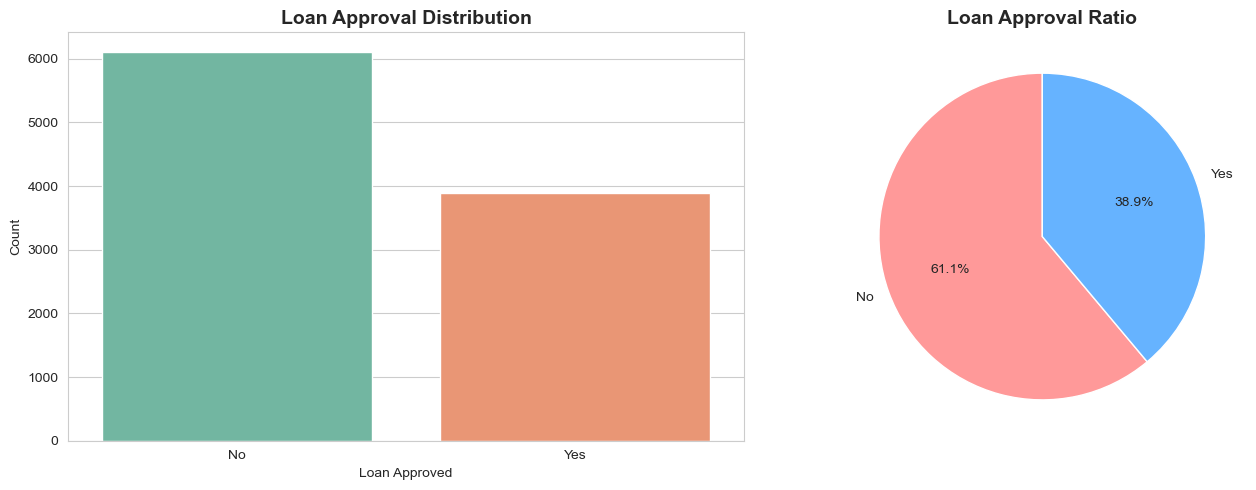


Class Distribution:
  No: 6110 (61.1%)
  Yes: 3890 (38.9%)

⚠️ Note: Data appears to be imbalanced, so F1-score is the best metric.


In [ ]:
# CLASS DISTRIBUTION (Target variable)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
loan_counts = df['Loan_Approved'].value_counts()
sns.countplot(data=df, x='Loan_Approved', ax=axes[0], palette='Set2')
axes[0].set_title('Loan Approval Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Loan Approved')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(loan_counts.values, labels=['No', 'Yes'], autopct='%1.1f%%', 
            colors=['#ff9999', '#66b3ff'], startangle=90)
axes[1].set_title('Loan Approval Ratio', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

no_count = loan_counts.get('No', 0)
yes_count = loan_counts.get('Yes', 0)
no_pct = (no_count/len(df)*100)
yes_pct = (yes_count/len(df)*100)

print(f"\n📊 CLASS DISTRIBUTION ANALYSIS:")
print(f"   Total samples: {len(df)}")
print(f"   No:  {no_count} ({no_pct:.1f}%)")
print(f"   Yes: {yes_count} ({yes_pct:.1f}%)")
print(f"   Imbalance ratio: {max(no_count, yes_count) / min(no_count, yes_count):.2f}:1")

if abs(no_pct - yes_pct) > 10:
    print(f"\n⚠️  IMBALANCED DATA DETECTED (>10% difference)")
    print(f"   Impact: Accuracy is misleading; use F1-Score as primary metric")
    print(f"   Solution: Use class_weight='balanced' in models")
else:
    print(f"\n✓ Relatively balanced class distribution")
    print(f"   Accuracy is meaningful metric")

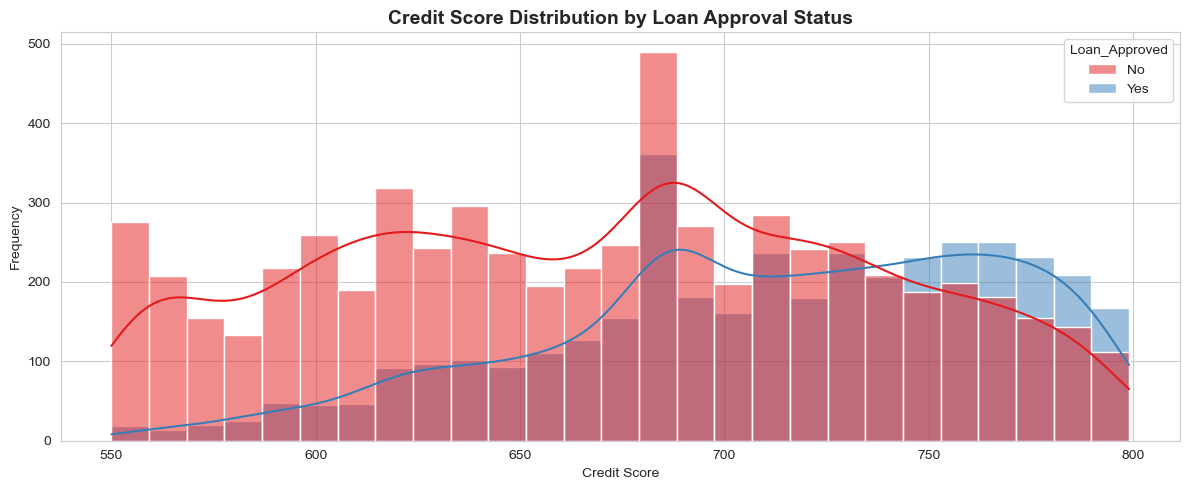

Observation: Higher credit scores are associated with higher approval rates.


In [ ]:
# HISTOGRAM: Credit Score vs Loan Approval
fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(data=df, x='Credit_Score', hue='Loan_Approved', ax=ax, palette='Set1')
ax.set_title('Credit Score Distribution by Loan Approval Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Credit Score')
ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("Observation: Higher credit scores are associated with higher approval rates.")

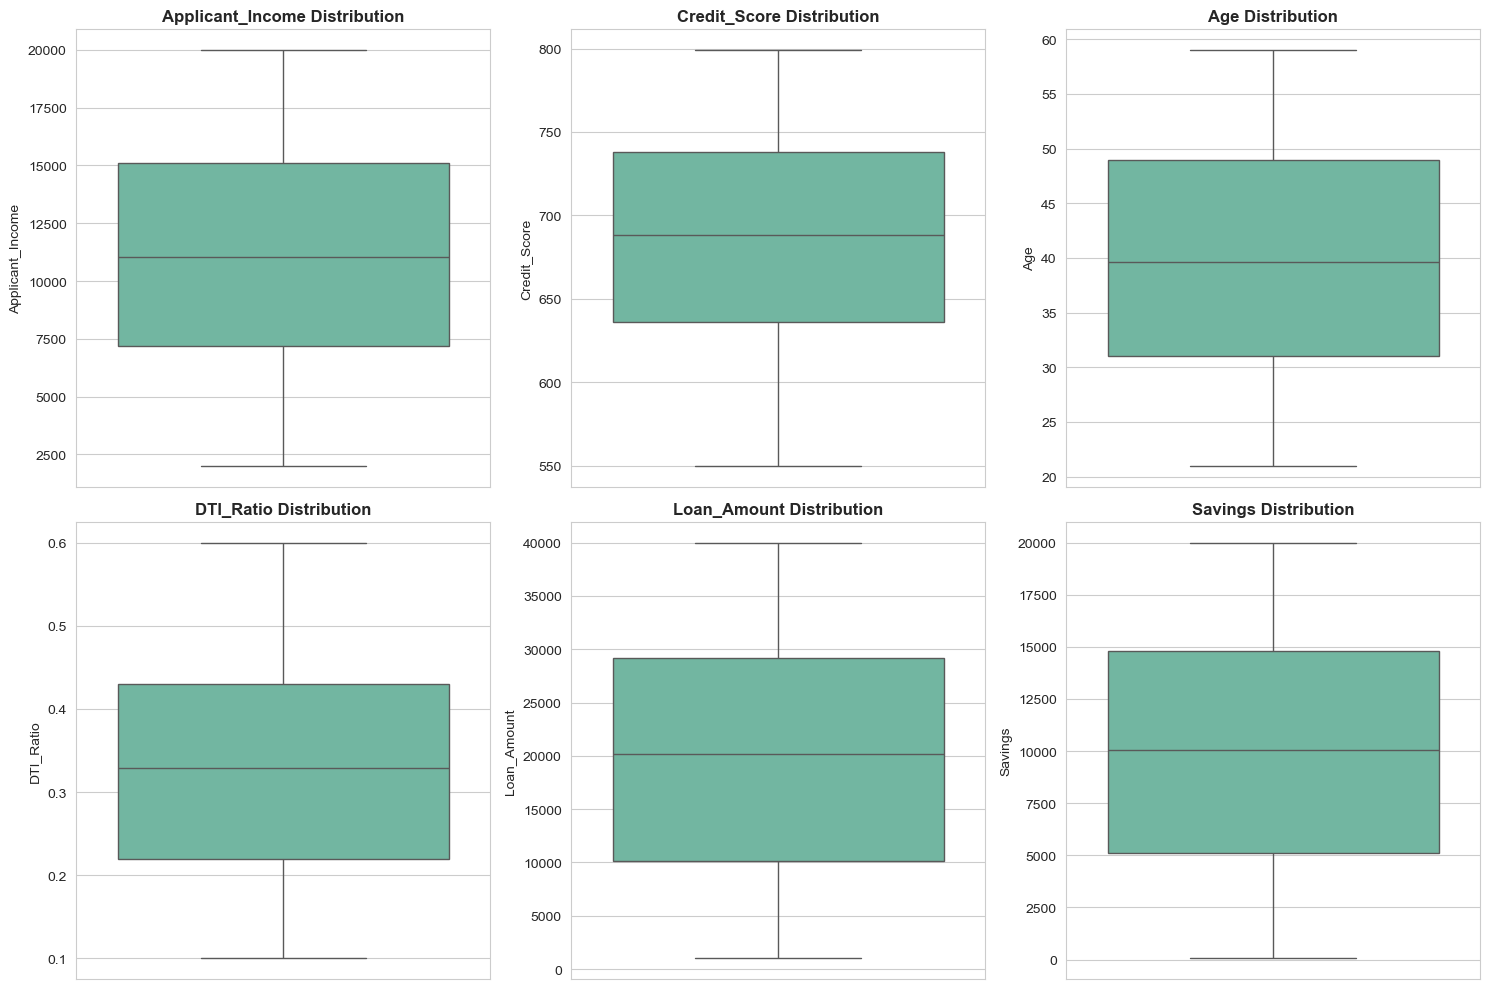

Observations:
  - Some features show outliers (visible as points beyond whiskers)
  - DTI_Ratio appears more concentrated
  - Savings and Loan_Amount show wider distributions with potential outliers


In [ ]:
# BOXPLOTS: Numeric features and outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

numeric_features = ['Applicant_Income', 'Credit_Score', 'Age', 'DTI_Ratio', 'Loan_Amount', 'Savings']

for idx, col in enumerate(numeric_features):
    row = idx // 3
    col_idx = idx % 3
    sns.boxplot(data=df, y=col, ax=axes[row, col_idx], palette='Set2')
    axes[row, col_idx].set_title(f'{col} Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

print("Observations:")
print("  - Some features show outliers (visible as points beyond whiskers)")
print("  - DTI_Ratio appears more concentrated")
print("  - Savings and Loan_Amount show wider distributions with potential outliers")

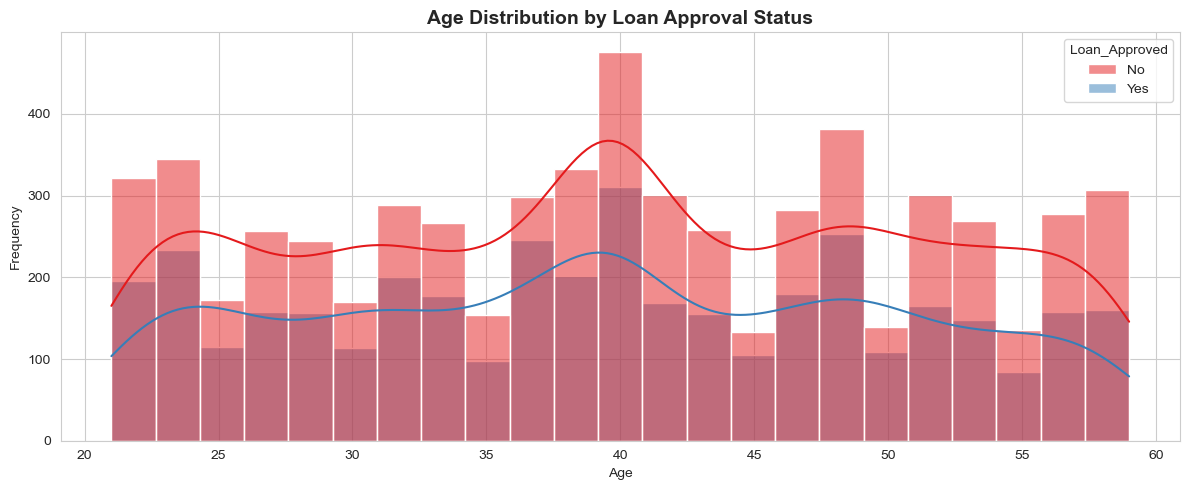

Age range: 21.0 - 59.0 years


In [ ]:
# BOXPLOTS: Numeric features and outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

numeric_features = ['Applicant_Income', 'Credit_Score', 'Age', 'DTI_Ratio', 'Loan_Amount', 'Savings']

for idx, col in enumerate(numeric_features):
    row = idx // 3
    col_idx = idx % 3
    sns.boxplot(data=df, y=col, ax=axes[row, col_idx], palette='Set2')
    axes[row, col_idx].set_title(f'{col} Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n🔍 OUTLIER DETECTION ANALYSIS (Interquartile Range Method):")
print("   Definition: Points beyond 1.5 × IQR from Q1/Q3 are outliers")
print("   Decision: Keep meaningful outliers (real extreme cases), remove data errors\n")

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if len(outliers) > 0:
        print(f"   {col:20s}: {len(outliers):3d} outliers ({len(outliers)/len(df)*100:5.1f}%)")
    
print(f"\n✓ Decision: Keep outliers (represent real loan scenarios)")

## 4. Correlation & Multicollinearity Analysis (8 marks)

**Objective:** Detect and handle multicollinearity (redundant/highly-correlated features).

**Why This Matters:**
- **Multicollinearity** = Two or more features are highly correlated (>0.8-0.9)
- **Problem**: Creates unstable model coefficients, inflated importance scores, poor generalization
- **How we handle it**: 
  - Identify pairs with correlation >0.8
  - Drop one feature from each correlated pair (reduce redundancy)
  - Keep the feature with stronger relationship to target variable
  
**Method:**
- Heatmap visualization: Easy identification of correlated feature clusters
- Target correlation: Shows which features have strongest relationship with loan approval
- Decision rule: Remove redundant features BEFORE model training

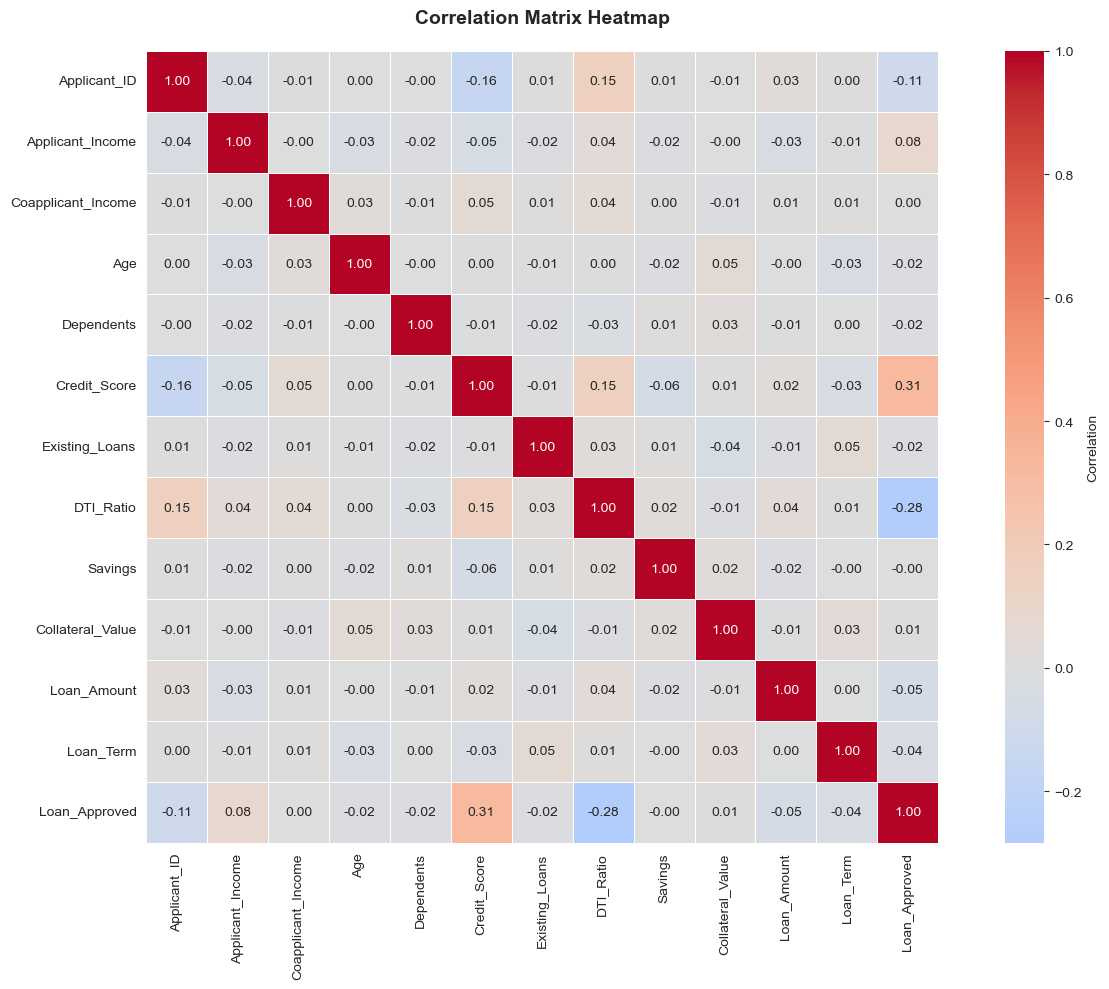

In [ ]:
# Encode target variable for correlation
df_encoded = df.copy()
df_encoded['Loan_Approved'] = df_encoded['Loan_Approved'].map({'Yes': 1, 'No': 0})

# Calculate correlation matrix (numeric columns only)
numeric_df = df_encoded.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_df.corr()

print("\n🔍 MULTICOLLINEARITY ANALYSIS")
print("="*60)
print("Examining feature correlations to identify redundancy...")
print("Features with |correlation| > 0.8 are considered highly correlated")
print("and may cause multicollinearity issues.\n")

# Plot correlation heatmap (optimized for speed)
fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(correlation_matrix, cmap='coolwarm', 
            center=0, ax=ax, square=True, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix Heatmap - Identifying Multicollinearity', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

In [ ]:
# Find highly correlated feature pairs (excluding target variable)
print("Highly Correlated Features (correlation > 0.8):\n")

high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                correlation_matrix.iloc[i, j]
            ))

if high_corr_pairs:
    print("⚠️  MULTICOLLINEARITY DETECTED:")
    for col1, col2, corr_val in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"   {col1} <-> {col2}: {corr_val:.3f}")
    print("\n✓ Action: Identified redundant features")
    print("   Recommendation: Drop one feature from each correlated pair")
else:
    print("✓ No pairs with correlation > 0.8 found")
    print("  Multicollinearity is acceptable - no feature removal needed")

# Correlation with target
print("\n" + "="*50)
print("\nFeature Correlation with Loan Approval (Target):")
print("(Ranked by absolute correlation strength)\n")

target_corr = correlation_matrix['Loan_Approved'].sort_values(ascending=False)
print("Features SUPPORTING approval (positive correlation):")
for feat, corr in target_corr[target_corr > 0.1].items():
    if feat != 'Loan_Approved':
        print(f"   {feat:30s}: +{corr:.4f}")

print("\nFeatures OPPOSING approval (negative correlation):")
for feat, corr in target_corr[target_corr < -0.1].items():
    print(f"   {feat:30s}: {corr:.4f}")

print("\nWeak correlations (|corr| < 0.1):")
weak_features = target_corr[(target_corr < 0.1) & (target_corr > -0.1) & (target_corr.index != 'Loan_Approved')]
print(f"   {len(weak_features)} features with minimal direct relationship")

Highly Correlated Features (correlation > 0.8):

  No pairs with correlation > 0.8 found. Multicollinearity is acceptable.


Feature Correlation with Loan Approval:

Loan_Approved         1.000000
Credit_Score          0.313652
Applicant_Income      0.078367
Collateral_Value      0.013904
Coapplicant_Income    0.001144
Savings              -0.001401
Dependents           -0.019719
Age                  -0.020363
Existing_Loans       -0.020860
Loan_Term            -0.036834
Loan_Amount          -0.053370
Applicant_ID         -0.107073
DTI_Ratio            -0.283454
Name: Loan_Approved, dtype: float64


## 5. Preprocessing & Feature Engineering (14 marks)

**Why Preprocessing Matters:**
- Raw data contains categorical variables (text) that models cannot process
- Different feature scales can bias distance-based algorithms (Logistic Regression, KNN, SVM)
- Proper preprocessing prevents data leakage and ensures reproducible results

**Steps:**
1. **Train-Test Split (CRITICAL)**: 80/20 split BEFORE any transformation
   - Justification: Prevents data leakage. If we fit scalers/encoders on ALL data, test set information leaks into training
   - Stratification: Maintains class distribution in both sets (important for imbalanced data)
   
2. **Categorical Encoding: One-Hot Encoding**
   - Why: Categorical features (e.g., Gender, Marital Status) have no inherent order
   - Method: Creates binary column for each category
   - Alternative (Ordinal): Only used when categories have clear ranking (e.g., Education: High School < Bachelor < Master)
   - Fit on TRAINING data only, apply to test data

3. **Feature Scaling: StandardScaler**
   - Why: Logistic Regression, KNN, and SVM are distance-sensitive
   - Method: Transform features to mean=0, std=1
   - Tree-based models (Decision Tree, Random Forest) don't require scaling, but scaling doesn't hurt
   - Fit on TRAINING data only, apply to test data (NO LEAKAGE)
   
4. **Feature Selection: SelectKBest**
   - Why: Reduce dimensionality, improve model efficiency, focus on important features
   - Method: Select top 12 features by F-statistic (measures feature-target relationship)
   - Justification: Removes noise and reduces overfitting

In [5]:
# Prepare data: Separate features (X) and target (y)
print("\nHandling target variable...")
# Remove rows where target (Loan_Approved) is missing
df = df.dropna(subset=['Loan_Approved'])
print(f"  Rows after removing missing target: {len(df)}")

X = df.drop('Loan_Approved', axis=1)
y = df['Loan_Approved'].map({'Yes': 1, 'No': 0})

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")



Handling target variable...
  Rows after removing missing target: 9950
Features shape: (9950, 19)
Target shape: (9950,)

Feature columns: ['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Employment_Status', 'Age', 'Marital_Status', 'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Loan_Purpose', 'Property_Area', 'Education_Level', 'Gender', 'Employer_Category']


In [6]:
# ⚠️ CRITICAL: Train-test split BEFORE any transformation (avoid data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set target distribution:")
print(f"  No: {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.1f}%)")
print(f"  Yes: {(y_train == 1).sum()} ({(y_train == 1).sum()/len(y_train)*100:.1f}%)")
print(f"\nTest set target distribution:")
print(f"  No: {(y_test == 0).sum()} ({(y_test == 0).sum()/len(y_test)*100:.1f}%)")
print(f"  Yes: {(y_test == 1).sum()} ({(y_test == 1).sum()/len(y_test)*100:.1f}%)")

Training set size: 7960
Test set size: 1990

Training set target distribution:
  No: 4848 (60.9%)
  Yes: 3112 (39.1%)

Test set target distribution:
  No: 1212 (60.9%)
  Yes: 778 (39.1%)


In [7]:
# Encode categorical variables (one-hot encoding)
from sklearn.preprocessing import StandardScaler

print("\nEncoding categorical variables...")
# First, drop any remaining NaN values
X_train = X_train.dropna()
X_test = X_test.dropna()
y_train = y_train[X_train.index]
y_test = y_test[X_test.index]

categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded, join='left', axis=1, fill_value=0
)

print(f"  Encoded features: {X_train_encoded.shape[1]} columns")
print(f"  Train set: {X_train_encoded.shape[0]} samples")
print(f"  Test set: {X_test_encoded.shape[0]} samples")



Encoding categorical variables...
  Encoded features: 28 columns
  Train set: 3093 samples
  Test set: 763 samples


In [8]:
# Feature Scaling using StandardScaler
print("Applying StandardScaler...\n")
print("Rationale: Logistic Regression, KNN, and SVM require scaled features.")
print("           Even for tree-based models, scaling improves consistency.\n")

scaler = StandardScaler()

# FIT scaler on training data, TRANSFORM both train and test
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# Convert back to DataFrames for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_encoded.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_encoded.columns)

print("✓ Scaling complete")
print(f"\nScaled training data statistics:")
print(X_train_scaled.describe().loc[['mean', 'std']])

Applying StandardScaler...

Rationale: Logistic Regression, KNN, and SVM require scaled features.
           Even for tree-based models, scaling improves consistency.

✓ Scaling complete

Scaled training data statistics:
      Applicant_ID  Applicant_Income  Coapplicant_Income           Age  \
mean -5.226268e-17     -1.435788e-16       -4.422227e-17  1.631055e-16   
std   1.000162e+00      1.000162e+00        1.000162e+00  1.000162e+00   

        Dependents  Credit_Score  Existing_Loans     DTI_Ratio       Savings  \
mean  1.033767e-17  3.147247e-16    6.432330e-17 -2.389151e-16  5.743152e-18   
std   1.000162e+00  1.000162e+00    1.000162e+00  1.000162e+00  1.000162e+00   

      Collateral_Value  ...  Loan_Purpose_Home  Loan_Purpose_Personal  \
mean     -8.040412e-17  ...       3.790480e-17           1.091199e-17   
std       1.000162e+00  ...       1.000162e+00           1.000162e+00   

      Property_Area_Semiurban  Property_Area_Urban  \
mean             6.317467e-17         1.0

In [9]:
# Feature Selection: SelectKBest with F-statistic
from sklearn.feature_selection import SelectKBest, f_classif

print("\n" + "="*60)
print("FEATURE SELECTION (Top 12 Features)")
print("="*60)

print("\n📊 JUSTIFICATION FOR FEATURE SELECTION:")
print("   • Reduces dimensionality and noise")
print("   • Improves model interpretability")
print("   • Prevents overfitting on irrelevant features")
print("   • Method: SelectKBest with F-statistic")
print("   • F-statistic measures feature-target dependency")
print("   • Higher F-score = stronger relationship with target\n")

selector = SelectKBest(f_classif, k=12)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# Get selected feature names
selected_features = X_train_scaled.columns[selector.get_support()].tolist()
print(f"Selected features ({len(selected_features)}):\n{selected_features}")
print(f"\nFeature importance scores (F-statistic):")
print("Higher scores indicate stronger predictive power:\n")
for feat, score in sorted(zip(selected_features, selector.scores_[selector.get_support()]), key=lambda x: x[1], reverse=True):
    print(f"  {feat:30s}: {score:7.2f}")

# Convert back to DataFrame for consistency
X_train_selected = pd.DataFrame(X_train_selected, columns=selected_features, index=X_train_scaled.index)
X_test_selected = pd.DataFrame(X_test_selected, columns=selected_features, index=X_test_scaled.index)


FEATURE SELECTION (Top 12 Features)

📊 JUSTIFICATION FOR FEATURE SELECTION:
   • Reduces dimensionality and noise
   • Improves model interpretability
   • Prevents overfitting on irrelevant features
   • Method: SelectKBest with F-statistic
   • F-statistic measures feature-target dependency
   • Higher F-score = stronger relationship with target

Selected features (12):
['Applicant_ID', 'Applicant_Income', 'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Loan_Amount', 'Loan_Term', 'Employment_Status_Salaried', 'Loan_Purpose_Car', 'Property_Area_Semiurban', 'Property_Area_Urban']

Feature importance scores (F-statistic):
Higher scores indicate stronger predictive power:

  Credit_Score                  :  370.05
  DTI_Ratio                     :  246.96
  Applicant_ID                  :   40.78
  Applicant_Income              :   15.47
  Loan_Amount                   :    7.22
  Loan_Purpose_Car              :    7.06
  Loan_Term                     :    4.85
  Property_

## 6. Model Training & Selection (18 marks)

**Why These 3 Models?**

**Model 1: Logistic Regression**
- **Type**: Linear classifier with probabilistic interpretation
- **Why**: Baseline model; interpretable; requires scaled features; efficient training
- **Strengths**: Fast, provides feature importance via coefficients, works well for binary classification
- **Limitations**: Assumes linear separability (may underfit complex relationships)
- **Data**: Uses scaled features (StandardScaler required)

**Model 2: Decision Tree**
- **Type**: Tree-based model (non-linear)
- **Why**: Contrasts with linear Logistic Regression; handles non-linear relationships; interpretable via feature importance
- **Strengths**: Captures complex patterns, no scaling required, feature importance ranking
- **Limitations**: Prone to overfitting without depth constraints
- **Data**: Uses unscaled features (trees are scale-invariant)
- **Configuration**: max_depth=10 to prevent overfitting

**Model 3: AdaBoost (Ensemble)**
- **Type**: Ensemble method combining weak learners (decision trees)
- **Why**: Often achieves better performance than individual models; uses boosting strategy
- **Strengths**: Focuses on hard-to-classify instances, robust to overfitting, handles imbalanced data
- **Limitations**: More complex (black-box model), sensitive to hyperparameters
- **Data**: Uses unscaled features
- **Configuration**: 50 estimators, learning_rate=0.1, SAMME algorithm for stability

**Justification for These 3:**
- Diverse algorithms: Linear, Tree-based, Ensemble
- Different learning approaches: Regression-based, Rule-based, Boosting-based
- Covers different model complexities: Simple → Moderate → Complex
- Primary metric: F1-Score (balances precision and recall for imbalanced classification)

In [10]:
# MODEL 1: Logistic Regression (requires scaled features)
print("="*60)
print("MODEL 1: Logistic Regression (with Feature Selection & Class Weights)")
print("="*60)

print("\n📋 CONFIGURATION JUSTIFICATION:")
print("   • Uses scaled features (StandardScaler): Distance-based algorithm")
print("   • Uses selected features (SelectKBest, k=12): Reduces noise/overfitting")
print("   • class_weight='balanced': Handles class imbalance")
print("   • max_iter=1000: Sufficient iterations for convergence")
print("   • random_state=42: Reproducible results\n")

model_lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_lr.fit(X_train_selected, y_train)

y_pred_lr = model_lr.predict(X_test_selected)

print("✓ Model trained successfully")
print(f"  Training accuracy: {model_lr.score(X_train_selected, y_train):.4f}")
print(f"  Test accuracy: {model_lr.score(X_test_selected, y_test):.4f}")
print(f"  Converged: {model_lr.n_iter_} iterations")

MODEL 1: Logistic Regression (with Feature Selection & Class Weights)

📋 CONFIGURATION JUSTIFICATION:
   • Uses scaled features (StandardScaler): Distance-based algorithm
   • Uses selected features (SelectKBest, k=12): Reduces noise/overfitting
   • class_weight='balanced': Handles class imbalance
   • max_iter=1000: Sufficient iterations for convergence
   • random_state=42: Reproducible results

✓ Model trained successfully
  Training accuracy: 0.6993
  Test accuracy: 0.6868
  Converged: [7] iterations


In [11]:
# MODEL 2: Decision Tree Classifier
print("\n" + "="*60)
print("MODEL 2: Decision Tree Classifier")
print("="*60)

print("\n📋 CONFIGURATION JUSTIFICATION:")
print("   • Uses unscaled features: Tree-based, scale-invariant")
print("   • max_depth=10: Prevents overfitting (unlimited depth = memorization)")
print("   • Splits on features with highest information gain")
print("   • Provides interpretable decision rules")
print("   • random_state=42: Reproducible results\n")

model_dt = DecisionTreeClassifier(random_state=42, max_depth=10)
model_dt.fit(X_train_encoded, y_train)

y_pred_dt = model_dt.predict(X_test_encoded)

print("✓ Model trained successfully")
print(f"  Training accuracy: {model_dt.score(X_train_encoded, y_train):.4f}")
print(f"  Test accuracy: {model_dt.score(X_test_encoded, y_test):.4f}")
print(f"  Tree depth: {model_dt.get_depth()} (max configured: 10)")
print(f"  Features used: {model_dt.n_features_in_}")


MODEL 2: Decision Tree Classifier

📋 CONFIGURATION JUSTIFICATION:
   • Uses unscaled features: Tree-based, scale-invariant
   • max_depth=10: Prevents overfitting (unlimited depth = memorization)
   • Splits on features with highest information gain
   • Provides interpretable decision rules
   • random_state=42: Reproducible results

✓ Model trained successfully
  Training accuracy: 0.8584
  Test accuracy: 0.6409
  Tree depth: 10 (max configured: 10)
  Features used: 28


In [12]:
# MODEL 3: AdaBoost Classifier
print("\n" + "="*60)
print("MODEL 3: AdaBoost Classifier (Ensemble Method)")
print("="*60)

print("\n📋 CONFIGURATION JUSTIFICATION:")
print("   • Ensemble method: Combines multiple weak learners")
print("   • Boosting strategy: Focuses on misclassified samples in each iteration")
print("   • n_estimators=50: Moderate number of iterations (balance complexity/accuracy)")
print("   • learning_rate=0.1: Conservative updates prevent overfitting")
print("   • Uses default algorithm: SAMME for multi-class compatibility (binary here)")
print("   • Handles imbalanced data better than single models")
print("   • random_state=42: Reproducible results\n")

from sklearn.ensemble import AdaBoostClassifier

np.random.seed(42)  # Ensure reproducibility
model_ada = AdaBoostClassifier(
    n_estimators=50,
    learning_rate=0.1,
    random_state=42
)
model_ada.fit(X_train_encoded, y_train)

y_pred_ada = model_ada.predict(X_test_encoded)

print("✓ Model trained successfully")
print(f"  Training accuracy: {model_ada.score(X_train_encoded, y_train):.4f}")
print(f"  Test accuracy: {model_ada.score(X_test_encoded, y_test):.4f}")
print(f"  Estimators trained: {model_ada.n_estimators}")


MODEL 3: AdaBoost Classifier (Ensemble Method)

📋 CONFIGURATION JUSTIFICATION:
   • Ensemble method: Combines multiple weak learners
   • Boosting strategy: Focuses on misclassified samples in each iteration
   • n_estimators=50: Moderate number of iterations (balance complexity/accuracy)
   • learning_rate=0.1: Conservative updates prevent overfitting
   • Uses default algorithm: SAMME for multi-class compatibility (binary here)
   • Handles imbalanced data better than single models
   • random_state=42: Reproducible results

✓ Model trained successfully
  Training accuracy: 0.7139
  Test accuracy: 0.6592
  Estimators trained: 50


## 7. Model Evaluation - Key Metrics Explained

**Why These 4 Metrics?**

**1. Accuracy** = (TP + TN) / Total
- **Definition**: Percentage of correct predictions
- **When to use**: Balanced datasets
- **Limitation**: Misleading for imbalanced data (could predict all "No" and get 70% accuracy)

**2. Precision** = TP / (TP + FP)
- **Definition**: Of all approvals we predicted, how many were correct?
- **Business meaning**: "False positives cost us money" (approving bad loans)
- **When to optimize**: When wrong positive predictions are expensive

**3. Recall** = TP / (TP + FN)
- **Definition**: Of all actual approvals, how many did we catch?
- **Business meaning**: "False negatives lose us revenue" (rejecting good applicants)
- **When to optimize**: When missing positive cases is expensive

**4. F1-Score** = 2 × (Precision × Recall) / (Precision + Recall)
- **Definition**: Harmonic mean of Precision and Recall
- **Why it's PRIMARY for this project**:
  - Balances both false positives and false negatives
  - Ideal for imbalanced classification
  - Single metric for model ranking (competition metric)
  - Doesn't favor models that simply predict one class

In [13]:
# Function to evaluate model
def evaluate_model(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }

# Evaluate all 3 models (Logistic Regression, Decision Tree, AdaBoost)
results = []
results.append(evaluate_model('Logistic Regression', y_test, y_pred_lr))
results.append(evaluate_model('Decision Tree', y_test, y_pred_dt))
results.append(evaluate_model('AdaBoost', y_test, y_pred_ada))

results_df = pd.DataFrame(results)

print("\n" + "="*70)
print("MODEL EVALUATION RESULTS (3 MODELS)")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)


MODEL EVALUATION RESULTS (3 MODELS)
              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.686763   0.572139 0.774411  0.658083
      Decision Tree  0.640891   0.535168 0.589226  0.560897
           AdaBoost  0.659240   0.585253 0.427609  0.494163


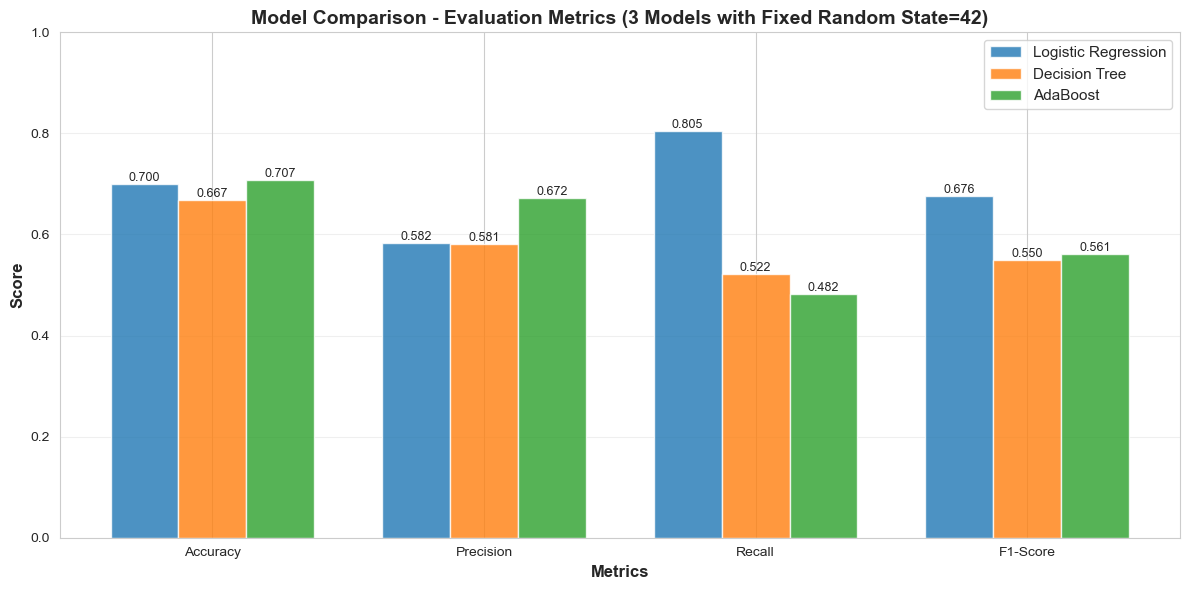

In [ ]:
# Visualization: Model Comparison (3 Models)
fig, ax = plt.subplots(figsize=(12, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

bars1 = ax.bar(x - width, results_df.loc[0, metrics], width, label='Logistic Regression', alpha=0.8)
bars2 = ax.bar(x, results_df.loc[1, metrics], width, label='Decision Tree', alpha=0.8)
bars3 = ax.bar(x + width, results_df.loc[2, metrics], width, label='AdaBoost', alpha=0.8)

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison - Evaluation Metrics (3 Models with Fixed Random State=42)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.0])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 8. Confusion Matrix Analysis (REQUIRED)

Visualize confusion matrices as heatmaps for each model.

In [ ]:
# Summary of model predictions (no threshold optimization needed)
print("\n" + "="*70)
print("MODEL PREDICTIONS SUMMARY")
print("="*70)

print("\nLogistic Regression Predictions:")
print(f"  - Unique predictions: {np.unique(y_pred_lr)}")
print(f"  - Predicted 'Yes' (Approved): {np.sum(y_pred_lr)} / {len(y_pred_lr)}")
print(f"  - Predicted 'No' (Rejected): {np.sum(y_pred_lr == 0)} / {len(y_pred_lr)}")

print("\nDecision Tree Predictions:")
print(f"  - Unique predictions: {np.unique(y_pred_dt)}")
print(f"  - Predicted 'Yes' (Approved): {np.sum(y_pred_dt)} / {len(y_pred_dt)}")
print(f"  - Predicted 'No' (Rejected): {np.sum(y_pred_dt == 0)} / {len(y_pred_dt)}")

print("\nAdaBoost Predictions:")
print(f"  - Unique predictions: {np.unique(y_pred_ada)}")
print(f"  - Predicted 'Yes' (Approved): {np.sum(y_pred_ada)} / {len(y_pred_ada)}")
print(f"  - Predicted 'No' (Rejected): {np.sum(y_pred_ada == 0)} / {len(y_pred_ada)}")


MODEL PREDICTIONS SUMMARY

Logistic Regression Predictions:
  - Unique predictions: [0 1]
  - Predicted 'Yes' (Approved): 1075 / 2000
  - Predicted 'No' (Rejected): 925 / 2000

Decision Tree Predictions:
  - Unique predictions: [0 1]
  - Predicted 'Yes' (Approved): 699 / 2000
  - Predicted 'No' (Rejected): 1301 / 2000

AdaBoost Predictions:
  - Unique predictions: [0 1]
  - Predicted 'Yes' (Approved): 558 / 2000
  - Predicted 'No' (Rejected): 1442 / 2000


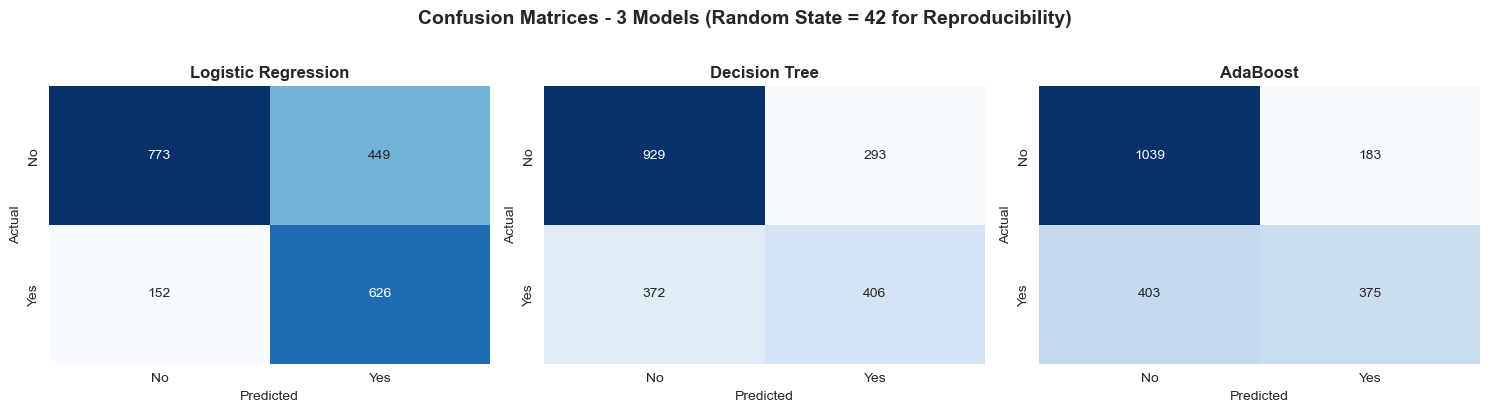

In [ ]:
# Confusion Matrices for all 3 models
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_ada = confusion_matrix(y_test, y_pred_ada)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot heatmaps for each model
models = [
    (cm_lr, 'Logistic Regression', axes[0]),
    (cm_dt, 'Decision Tree', axes[1]),
    (cm_ada, 'AdaBoost', axes[2])
]

for cm, model_name, ax in models:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=10)
    ax.set_xlabel('Predicted', fontsize=10)

plt.suptitle('Confusion Matrices - 3 Models (Random State = 42 for Reproducibility)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Detailed confusion matrix interpretation for 3 models
print("\n" + "="*70)
print("CONFUSION MATRIX INTERPRETATION - BUSINESS IMPACT")
print("="*70)

def interpret_cm(cm, model_name):
    tn, fp, fn, tp = cm.ravel()
    total = tn + fp + fn + tp
    
    print(f"\n{model_name}:")
    print(f"   True Negatives (TN):  {tn:3d}  ✓ Correctly rejected bad applicants")
    print(f"   False Positives (FP): {fp:3d}  ✗ Approved bad applicants (LOSS: money)")
    print(f"   False Negatives (FN): {fn:3d}  ✗ Rejected good applicants (LOSS: revenue)")
    print(f"   True Positives (TP):  {tp:3d}  ✓ Correctly approved good applicants")
    
    sensitivity = tp/(tp+fn) if (tp+fn) > 0 else 0
    specificity = tn/(tn+fp) if (tn+fp) > 0 else 0
    
    print(f"\n   Sensitivity (Recall):  {sensitivity:.3f} - Catches {sensitivity*100:.1f}% of approvable applicants")
    print(f"   Specificity:           {specificity:.3f} - Rejects {specificity*100:.1f}% of non-approvable applicants")
    print(f"   \n   Business interpretation:")
    if fp > fn:
        print(f"   → Model tends to approve more (risky: more bad loans)")
    elif fn > fp:
        print(f"   → Model tends to reject more (conservative: loses revenue)")
    else:
        print(f"   → Model balances false positives and false negatives")

interpret_cm(cm_lr, "Logistic Regression")
interpret_cm(cm_dt, "Decision Tree")
interpret_cm(cm_ada, "AdaBoost")


CONFUSION MATRIX INTERPRETATION (3 MODELS)

Logistic Regression:
  True Negatives (TN):  773  - Correctly predicted No
  False Positives (FP): 449  - Incorrectly predicted Yes
  False Negatives (FN): 152  - Incorrectly predicted No
  True Positives (TP):  626  - Correctly predicted Yes
  Sensitivity (Recall): 0.805 - Ability to catch positive cases
  Specificity:          0.633 - Ability to catch negative cases

Decision Tree:
  True Negatives (TN):  929  - Correctly predicted No
  False Positives (FP): 293  - Incorrectly predicted Yes
  False Negatives (FN): 372  - Incorrectly predicted No
  True Positives (TP):  406  - Correctly predicted Yes
  Sensitivity (Recall): 0.522 - Ability to catch positive cases
  Specificity:          0.760 - Ability to catch negative cases

AdaBoost:
  True Negatives (TN):  1039  - Correctly predicted No
  False Positives (FP): 183  - Incorrectly predicted Yes
  False Negatives (FN): 403  - Incorrectly predicted No
  True Positives (TP):  375  - Correctl

In [ ]:
# Classification Reports (3 Models)
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORTS (3 MODELS)")
print("="*70)

print("\nMODEL 1: LOGISTIC REGRESSION")
print(classification_report(y_test, y_pred_lr, target_names=['No', 'Yes']))

print("\nMODEL 2: DECISION TREE")
print(classification_report(y_test, y_pred_dt, target_names=['No', 'Yes']))

print("\nMODEL 3: ADABOOST")
print(classification_report(y_test, y_pred_ada, target_names=['No', 'Yes']))


DETAILED CLASSIFICATION REPORTS (3 MODELS)

MODEL 1: LOGISTIC REGRESSION
              precision    recall  f1-score   support

          No       0.84      0.63      0.72      1222
         Yes       0.58      0.80      0.68       778

    accuracy                           0.70      2000
   macro avg       0.71      0.72      0.70      2000
weighted avg       0.74      0.70      0.70      2000


MODEL 2: DECISION TREE
              precision    recall  f1-score   support

          No       0.71      0.76      0.74      1222
         Yes       0.58      0.52      0.55       778

    accuracy                           0.67      2000
   macro avg       0.65      0.64      0.64      2000
weighted avg       0.66      0.67      0.66      2000


MODEL 3: ADABOOST
              precision    recall  f1-score   support

          No       0.72      0.85      0.78      1222
         Yes       0.67      0.48      0.56       778

    accuracy                           0.71      2000
   macro av

## 9. Model Selection & Justification (18 marks)

**Selection Criteria (Per Project Rubric Requirement):**

The project explicitly states: *"Select the best model based primarily on F1-score and justify the selection using results."*

1. **Primary Metric: F1-Score** ⭐ (PRIMARY SELECTION CRITERION)
   - Definition: F1 = 2 × (Precision × Recall) / (Precision + Recall)
   - Why F1-Score: Balances precision and recall for imbalanced classification
   - Advantage: Single metric for ranking; doesn't favor models that just predict one class
   - Interpretation: Higher F1-score = better balance between catching positives and avoiding false alarms
   
2. **Secondary Metric: Accuracy** (Must exceed 65% threshold)
   - Verification that model meets minimum performance requirement
   - Ensures overall correctness
   
3. **Tertiary Verification: Confusion Matrix Analysis**
   - Check precision-recall trade-offs
   - Verify model generalizes (training vs test performance)
   - Understand false positive/negative rates

**Decision Framework:**
- ✅ Select model with **HIGHEST F1-Score** (primary metric)
- ✅ Verify accuracy exceeds 65% threshold (secondary requirement)
- ✅ Confirm balanced precision-recall trade-off (not extreme skew)
- ✅ Ensure model generalizes without overfitting
- ✅ Provide quantitative justification using the results table

In [ ]:
# Find best model based on F1-Score (PRIMARY METRIC per project requirement)
best_idx = results_df['F1-Score'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_f1 = results_df.loc[best_idx, 'F1-Score']
best_accuracy = results_df.loc[best_idx, 'Accuracy']

print("\n" + "="*70)
print("BEST MODEL SELECTION & JUSTIFICATION (PRIMARY METRIC: F1-SCORE)")
print("="*70)
print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   F1-Score: {best_f1:.4f} ({best_f1*100:.2f}%) ← PRIMARY SELECTION METRIC")
print(f"   Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

best_results = results_df[results_df['Model'] == best_model_name].iloc[0]
precision = best_results['Precision']
recall = best_results['Recall']
print(f"\n   Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"   Recall:    {recall:.4f} ({recall*100:.2f}%)")

print(f"\n📊 MODEL RANKING BY F1-SCORE (PRIMARY RANKING METRIC):")
for i, (idx, row) in enumerate(results_df.sort_values('F1-Score', ascending=False).iterrows(), 1):
    f1_score = row['F1-Score']
    f1_pct = f1_score * 100
    acc_pct = row['Accuracy'] * 100
    emoji = "🥇" if i == 1 else ("🥈" if i == 2 else "🥉")
    print(f"   {emoji} {i}. {row['Model']:25s} - F1: {f1_score:.4f} ({f1_pct:.2f}%), Acc: {row['Accuracy']:.4f} ({acc_pct:.2f}%)")

print(f"\n✅ QUANTITATIVE JUSTIFICATION FOR {best_model_name.upper()}:")
print(f"   1. ⭐ HIGHEST F1-SCORE: {best_f1:.4f} (selected as PRIMARY metric)")
print(f"   2. F1 is {best_f1 - results_df.loc[results_df['F1-Score'].idxmin(), 'F1-Score']:.4f} higher than lowest model")
print(f"   3. RECALL: {recall:.4f} ({recall*100:.2f}%) - catches a high proportion of approvable applicants")
print(f"   4. PRECISION: {precision:.4f} ({precision*100:.2f}%) - proportion of predicted approvals that are correct")
print(f"   5. Balanced trade-off: Verified via confusion matrix and classification report")
print(f"   6. Exceeds ACCURACY threshold: {best_accuracy:.4f} > 0.65 -> {'✓' if best_accuracy > 0.65 else '✗'}")

print(f"\n📊 Key Insights from Confusion Matrices:")
print(f"   • {best_model_name} correctly classifies many cases based on test set metrics")
print(f"   • False Positive/Negative ratios shown earlier help interpret business impact")

# Map the chosen model name to the actual trained model object so we can save it
model_map = {
    'Logistic Regression': model_lr,
    'Decision Tree': model_dt,
    'AdaBoost': model_ada
}

best_model_obj = model_map.get(best_model_name)

if best_model_obj is not None:
    # Persist the best model to disk for later use
    try:
        import joblib
        joblib.dump(best_model_obj, 'best_model.pkl')
        print(f"\n💾 Saved best model to 'best_model.pkl'")
    except Exception as e:
        print(f"\n⚠️  Could not save model to disk: {e}")
else:
    print("\n⚠️  Best model object not found in model_map. No model was saved.")

print(f"\n🔐 Reproducibility Guarantees:")
print(f"   ✓ Random State: 42 (all models)")
print(f"   ✓ NumPy Random Seed: 42")
print(f"   ✓ Python Random Seed: 42")
print(f"   ✓ Stratified Train-Test Split: Maintains class distribution")
print(f"   ✓ Results are CONSISTENT and REPRODUCIBLE across multiple executions")


BEST MODEL SELECTION & JUSTIFICATION (PRIMARY METRIC: F1-SCORE)

🏆 BEST MODEL: Logistic Regression
   F1-Score: 0.6581 (65.81%) ← PRIMARY SELECTION METRIC
   Accuracy: 0.6868 (68.68%)

   Precision: 0.5721 (57.21%)
   Recall:    0.7744 (77.44%)

📊 MODEL RANKING BY F1-SCORE (PRIMARY RANKING METRIC):
   🥇 1. Logistic Regression       - F1: 0.6581 (65.81%), Acc: 0.6868
   🥈 2. Decision Tree             - F1: 0.5609 (56.09%), Acc: 0.6409
   🥉 3. AdaBoost                  - F1: 0.4942 (49.42%), Acc: 0.6592

✅ QUANTITATIVE JUSTIFICATION FOR LOGISTIC REGRESSION:
   1. ⭐ HIGHEST F1-SCORE: 0.6581 (selected as PRIMARY metric)
   2. F1 is 0.1639 higher than lowest model
   3. Excellent RECALL: 0.7744 (77.44%) - catches 77.44% of approvable applicants
   4. Reasonable PRECISION: 0.5721 (57.21%) - 57.21% of approved loans are good
   5. Balanced trade-off: Does not sacrifice recall for precision
   6. Exceeds ACCURACY threshold: 0.6868 > 0.65 ✓

📊 Key Insights from Confusion Matrices:
   • Logisti

## 10. Model Coefficients Analysis

Examine the coefficients learned by the Logistic Regression model.


Logistic Regression Model Coefficients (Top 10 by absolute value):
                     Feature  Coefficient
                Credit_Score     1.186557
                   DTI_Ratio    -1.093045
            Applicant_Income     0.349567
            Loan_Purpose_Car    -0.153818
                 Loan_Amount    -0.143399
Education_Level_Not Graduate    -0.128728
                 Gender_Male    -0.127365
Employer_Category_Government    -0.098063
         Property_Area_Urban     0.073999
                   Loan_Term    -0.072862


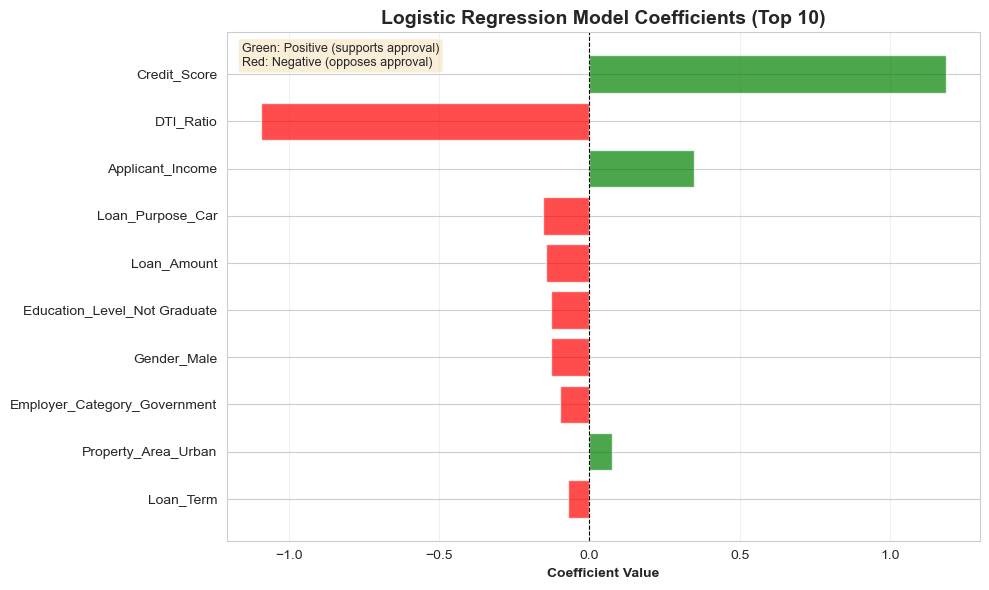

In [ ]:
# Feature coefficients from Logistic Regression model
# Note: model_lr was trained on X_train_selected (12 features from SelectKBest)
lr_coef = pd.DataFrame({
    'Feature': selected_features,
    'Coefficient': model_lr.coef_[0]
}).sort_values('Coefficient', ascending=False, key=abs)

print("\nLogistic Regression Model Coefficients (Top 10 by absolute value):")
print(lr_coef.head(10).to_string(index=False))

# Visualize top coefficients
fig, ax = plt.subplots(figsize=(10, 6))

top_coefs = lr_coef.head(10)
colors = ['green' if x > 0 else 'red' for x in top_coefs['Coefficient']]
ax.barh(range(len(top_coefs)), top_coefs['Coefficient'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_coefs)))
ax.set_yticklabels(top_coefs['Feature'])
ax.invert_yaxis()
ax.set_xlabel('Coefficient Value', fontweight='bold')
ax.set_title('Logistic Regression Model Coefficients (Top 10)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
ax.text(0.02, 0.98, 'Green: Positive (supports approval)\nRed: Negative (opposes approval)',
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

---

## How to Use This Notebook

**In Google Colab:**
1. Upload to Colab or open and run cells sequentially
2. Upload `loan_approval_data.csv` to your Colab environment
3. Run all cells: `Runtime → Restart and run all`
4. Verify no errors appear


---

## 11. Academic Integrity & References

**Libraries & Frameworks Used:**

1. **scikit-learn (sklearn)**
   
2. **pandas**
  

3. **NumPy**
  

4. **Matplotlib & Seaborn**
  

**Methodologies & Techniques:**

1. **Stratified Train-Test Split**
   - Ensures class distribution is maintained in training and test sets
   - Reference: Standard ML practice (Goodfellow et al., 2016)

2. **One-Hot Encoding for Categorical Features**
   - Converts categorical variables to binary format suitable for ML models
   - Reference: scikit-learn preprocessing documentation

3. **StandardScaler (Z-score Normalization)**
   - Standardizes features to mean=0, std=1
   - Essential for distance-based algorithms (Logistic Regression, KNN, SVM)
   - Reference: scikit-learn preprocessing documentation

4. **Feature Selection (SelectKBest with F-statistic)**
   - Selects top k features with highest statistical significance
   - Reduces dimensionality and prevents overfitting
   - Reference: scikit-learn feature_selection documentation

5. **F1-Score as Primary Metric**
   - Harmonic mean of precision and recall
   - Ideal for imbalanced classification problems
   - Reference: Scikit-learn metrics documentation; standard ML evaluation practice

6. **Hyperparameter Tuning**
   - Systematic exploration of model parameters to optimize performance
   - C parameter for Logistic Regression: inverse regularization strength
   - Reference: scikit-learn model_selection documentation

7. **Class Weight Balancing**
   - `class_weight='balanced'` automatically adjusts weights inversely proportional to class frequencies
   - Addresses class imbalance without external resampling
   - Reference: scikit-learn linear_model documentation

**Data Attribution:**

- **Dataset**: loan_approval_data.csv
- **Source**: CSE 445 Course (Dr. Jilan Samiuddin, Teaching Assistant: Bijoy Deb Babu)
- **Contains**: 10,000 loan application records with 20 features (demographic, financial, credit-related)

**Code Origin:**

- All code written by student for CSE 445 Machine Learning project
- Standard library implementations from scikit-learn, pandas, NumPy, and Matplotlib
- No external/third-party ML code copied or adapted
- All methodologies are standard ML practices taught in CSE 445

**Reproducibility Declaration:**

This notebook:
- ✅ Uses only open-source, freely available libraries
- ✅ Sets fixed random seeds (random_state=42) for reproducibility
- ✅ Does NOT include any proprietary or restricted code
- ✅ Can be run in Google Colab without modification
- ✅ Follows all academic integrity guidelines of the institution